# Heart Disease Detection (Modeling & Evaluation)

Trains and evaluates four supervised classification models on the preprocessed Cleveland Heart Disease dataset. We use stratified 5-fold cross-validation for hyperparameter tuning and report final performance on a held-out test set.

## 1. Setup

We load the preprocessed train/test splits saved by the preprocessing notebook

In [1]:
!pip install xgboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

warnings.filterwarnings('ignore')
os.makedirs('figures', exist_ok=True)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Color scheme 
COLOR_NO_DISEASE = '#4A90D9'
COLOR_DISEASE = '#E8833A'
COLOR_ACCENT = '#2C3E50'
MODEL_COLORS = {
    'Logistic Regression': '#4A90D9',
    'Random Forest': '#E8833A',
    'SVM': '#7F8C8D',
    'XGBoost': '#2C3E50',
}

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
})
sns.set_style('whitegrid')

In [2]:
# Load preprocessed data 
X_train = pd.read_csv('data/X_train.csv')
X_test = pd.read_csv('data/X_test.csv')
y_train = pd.read_csv('data/y_train.csv').squeeze()
y_test = pd.read_csv('data/y_test.csv').squeeze()

print(f'Training set: {X_train.shape[0]} samples × {X_train.shape[1]} features')
print(f'Test set:     {X_test.shape[0]} samples × {X_test.shape[1]} features')
print(f'Train class balance: {y_train.value_counts().to_dict()}')
print(f'Test class balance:  {y_test.value_counts().to_dict()}')

Training set: 242 samples × 18 features
Test set:     61 samples × 18 features
Train class balance: {0: 131, 1: 111}
Test class balance:  {0: 33, 1: 28}


## 2. Model Training with Hyperparameter Tuning

For each of the four models, we use stratified 5-fold cross-validation on the training set to select hyperparameters via grid search, optimizing for AUROC. The best hyperparameters are then used to refit the model on the full training set, and final performance is evaluated on the held-out test set.

In [3]:
# Define models and hyperparameter grids
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

model_configs = {
    'Logistic Regression': {
        'estimator': LogisticRegression(max_iter=2000, random_state=RANDOM_SEED),
        'param_grid': {
            'C': [0.01, 0.1, 1.0, 10.0],
            'penalty': ['l2'],
        },
    },
    'Random Forest': {
        'estimator': RandomForestClassifier(random_state=RANDOM_SEED),
        'param_grid': {
            'n_estimators': [100, 200, 500],
            'max_depth': [None, 5, 10],
            'min_samples_leaf': [1, 2, 4],
        },
    },
    'SVM': {
        'estimator': SVC(probability=True, random_state=RANDOM_SEED),
        'param_grid': {
            'C': [0.1, 1.0, 10.0],
            'gamma': ['scale', 'auto'],
            'kernel': ['rbf'],
        },
    },
    'XGBoost': {
        'estimator': XGBClassifier(
            random_state=RANDOM_SEED,
            use_label_encoder=False,
            eval_metric='logloss',
        ),
        'param_grid': {
            'n_estimators': [100, 200],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.05, 0.1, 0.2],
        },
    },
}

# Train each model with grid search
trained_models = {}
best_params = {}

for name, config in model_configs.items():
    print(f'\nTraining {name}...')
    grid = GridSearchCV(
        estimator=config['estimator'],
        param_grid=config['param_grid'],
        scoring='roc_auc',
        cv=cv,
        n_jobs=-1,
    )
    grid.fit(X_train, y_train)
    trained_models[name] = grid.best_estimator_
    best_params[name] = grid.best_params_
    print(f'  Best CV AUROC: {grid.best_score_:.4f}')
    print(f'  Best params:   {grid.best_params_}')


Training Logistic Regression...
  Best CV AUROC: 0.9093
  Best params:   {'C': 1.0, 'penalty': 'l2'}

Training Random Forest...
  Best CV AUROC: 0.8999
  Best params:   {'max_depth': None, 'min_samples_leaf': 4, 'n_estimators': 100}

Training SVM...
  Best CV AUROC: 0.8926
  Best params:   {'C': 1.0, 'gamma': 'auto', 'kernel': 'rbf'}

Training XGBoost...
  Best CV AUROC: 0.8696
  Best params:   {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}


## 3. Test Set Evaluation

Each tuned model is evaluated on the held-out test set using AUROC, accuracy, precision, recall, and F1-score. AUROC is the primary metric.

In [4]:
# Evaluate each model on the test set
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'AUROC': roc_auc_score(y_test, y_proba),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
    })

results_df = pd.DataFrame(results).set_index('Model').round(4)
print('Test set performance:\n')
print(results_df.to_string())

# Save to CSV for the report
results_df.to_csv('model_results.csv')

Test set performance:

                      AUROC  Accuracy  Precision  Recall      F1
Model                                                           
Logistic Regression  0.9567    0.8525     0.8065  0.8929  0.8475
Random Forest        0.9610    0.8852     0.8621  0.8929  0.8772
SVM                  0.9589    0.9344     0.9286  0.9286  0.9286
XGBoost              0.9264    0.8689     0.8333  0.8929  0.8621


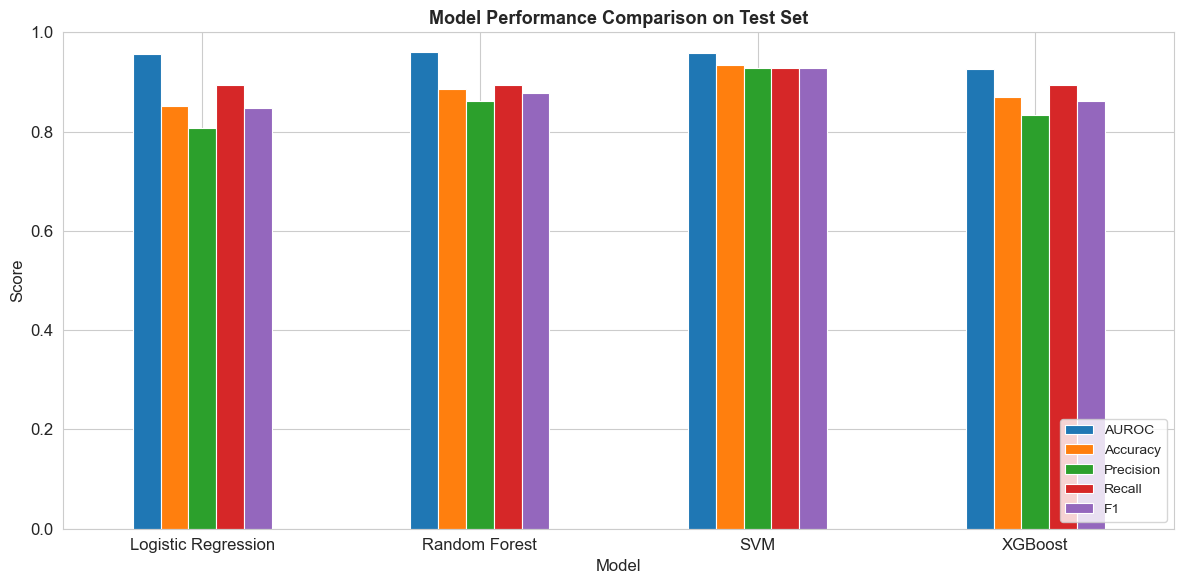

In [5]:
# Bar chart comparing all models across all metrics
fig, ax = plt.subplots(figsize=(12, 6))
results_df.plot(kind='bar', ax=ax, edgecolor='white', linewidth=0.8)
ax.set_title('Model Performance Comparison on Test Set')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('figures/model_comparison.png')
plt.show()

## 4. ROC Curves

ROC curves visualize the trade-off between true positive rate (recall) and false positive rate across all classification thresholds. A model that hugs the upper-left corner has the best discriminative ability.

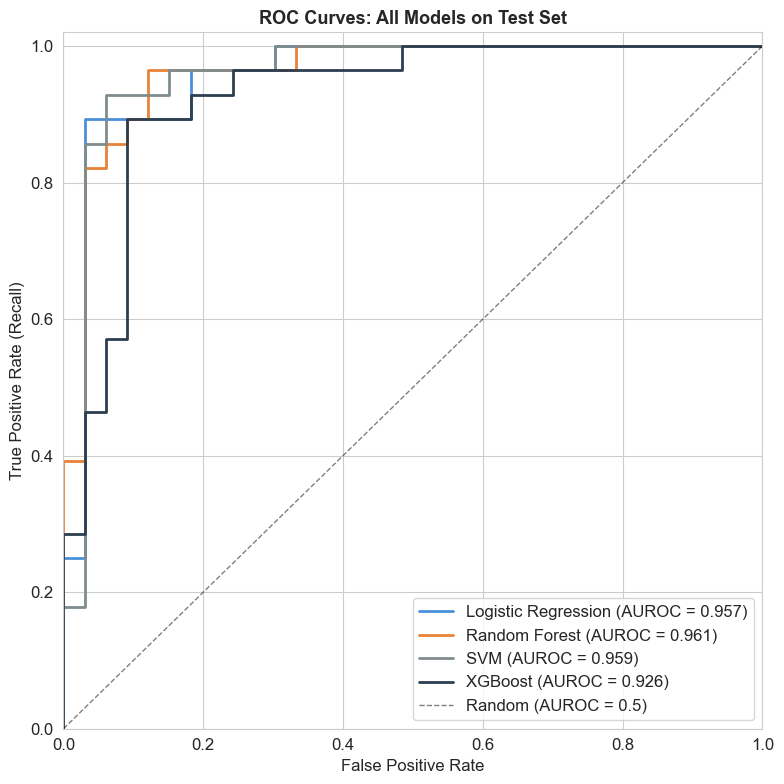

In [6]:
fig, ax = plt.subplots(figsize=(8, 8))

for name, model in trained_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, color=MODEL_COLORS[name], lw=2,
            label=f'{name} (AUROC = {auc:.3f})')

# Diagonal reference line (random classifier)
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random (AUROC = 0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curves: All Models on Test Set')
ax.legend(loc='lower right')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.savefig('figures/roc_curves.png')
plt.show()

## 5. Best Model: Detailed Analysis

We identify the best model by AUROC and inspect its confusion matrix and classification report.

Best model: Random Forest (AUROC = 0.9610)


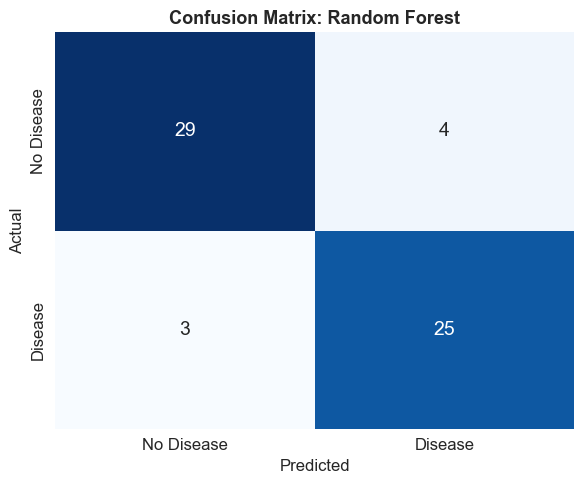


Classification Report for Random Forest:
              precision    recall  f1-score   support

  No Disease       0.91      0.88      0.89        33
     Disease       0.86      0.89      0.88        28

    accuracy                           0.89        61
   macro avg       0.88      0.89      0.88        61
weighted avg       0.89      0.89      0.89        61



In [7]:
# Identify best model
best_model_name = results_df['AUROC'].idxmax()
best_model = trained_models[best_model_name]
print(f'Best model: {best_model_name} (AUROC = {results_df.loc[best_model_name, "AUROC"]:.4f})')

# Confusion matrix
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'],
            cbar=False, ax=ax, annot_kws={'size': 14})
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix: {best_model_name}')
plt.tight_layout()
plt.savefig('figures/confusion_matrix.png')
plt.show()

# Detailed classification report
print(f'\nClassification Report for {best_model_name}:')
print(classification_report(y_test, y_pred_best,
                            target_names=['No Disease', 'Disease']))

## 6. Feature Importance

For tree-based models (Random Forest, XGBoost), we examine which features the model relied on most. This helps verify that the model's reasoning aligns with known cardiology risk factors and supports clinical interpretability.

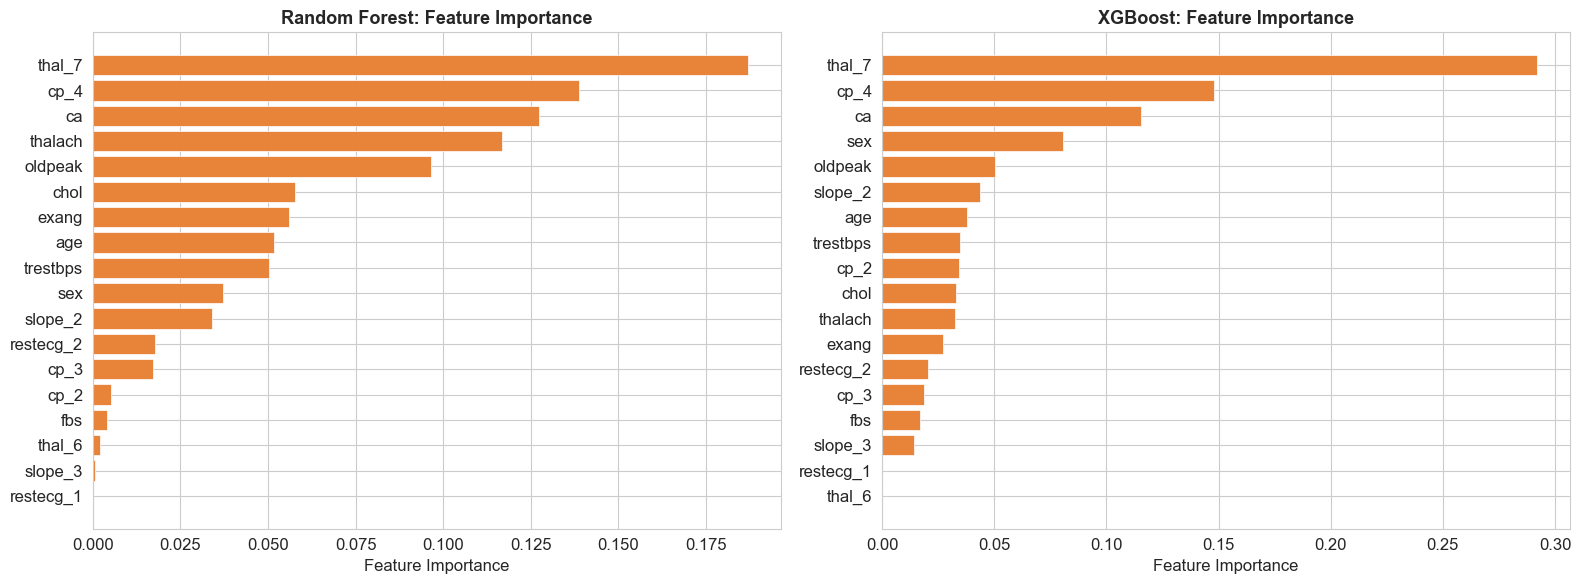


Top 5 features (Random Forest):
           thal_7: 0.1871
             cp_4: 0.1387
               ca: 0.1273
          thalach: 0.1168
          oldpeak: 0.0964

Top 5 features (XGBoost):
           thal_7: 0.2922
             cp_4: 0.1481
               ca: 0.1155
              sex: 0.0806
          oldpeak: 0.0506


In [8]:
# Feature importance from Random Forest and XGBoost
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, model_name in zip(axes, ['Random Forest', 'XGBoost']):
    model = trained_models[model_name]
    importances = pd.Series(model.feature_importances_, index=X_train.columns)
    importances = importances.sort_values(ascending=True)

    ax.barh(importances.index, importances.values,
            color=COLOR_DISEASE, edgecolor='white', linewidth=0.5)
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'{model_name}: Feature Importance')

plt.tight_layout()
plt.savefig('figures/feature_importance.png')
plt.show()

# Print top 5 features for each
for model_name in ['Random Forest', 'XGBoost']:
    model = trained_models[model_name]
    importances = pd.Series(model.feature_importances_, index=X_train.columns)
    top5 = importances.sort_values(ascending=False).head(5)
    print(f'\nTop 5 features ({model_name}):')
    for feat, score in top5.items():
        print(f'  {feat:>15}: {score:.4f}')

## 7. Summary

Consolidates the key findings from model evaluation for use in the final report.

In [9]:
print('=' * 60)
print('MODELING SUMMARY')
print('=' * 60)
print(f'\nDataset: {X_train.shape[0]} train + {X_test.shape[0]} test patients')
print(f'\nBest model: {best_model_name}')
print(f'Best AUROC:    {results_df.loc[best_model_name, "AUROC"]:.4f}')
print(f'Accuracy:      {results_df.loc[best_model_name, "Accuracy"]:.4f}')
print(f'Precision:     {results_df.loc[best_model_name, "Precision"]:.4f}')
print(f'Recall:        {results_df.loc[best_model_name, "Recall"]:.4f}')
print(f'F1-Score:      {results_df.loc[best_model_name, "F1"]:.4f}')
print(f'\nBest hyperparameters: {best_params[best_model_name]}')
print('\nFull results table:')
print(results_df.to_string())

MODELING SUMMARY

Dataset: 242 train + 61 test patients

Best model: Random Forest
Best AUROC:    0.9610
Accuracy:      0.8852
Precision:     0.8621
Recall:        0.8929
F1-Score:      0.8772

Best hyperparameters: {'max_depth': None, 'min_samples_leaf': 4, 'n_estimators': 100}

Full results table:
                      AUROC  Accuracy  Precision  Recall      F1
Model                                                           
Logistic Regression  0.9567    0.8525     0.8065  0.8929  0.8475
Random Forest        0.9610    0.8852     0.8621  0.8929  0.8772
SVM                  0.9589    0.9344     0.9286  0.9286  0.9286
XGBoost              0.9264    0.8689     0.8333  0.8929  0.8621
